# Orthopedic Foundation Model (Synthetic Demo)
This notebook demonstrates an assumption-based experimental setup inspired by:
- 300k X-rays, 17k patients, 72 hospitals
- Multi-view per patient (femur/pelvis, AP/LAT)
- No labels available for pretraining

We will:
1) Create a synthetic multi-hospital, multi-view X-ray-like dataset
2) Train a self-supervised encoder (SimCLR-style)
3) Evaluate representation quality + hospital generalization
4) Fine-tune on downstream tasks with limited labels


In [2]:
!pip -q install tensorflow scikit-learn matplotlib


import os, math, random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.manifold import TSNE

print("TF version:", tf.__version__)

SEED = 7
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 735.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 117.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 19.1 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


TF version: 2.20.0


## 1) Synthetic Data Assumptions
We simulate:
- 72 hospitals → domain shift (contrast/brightness/noise/blur)
- Each patient has multiple images (views & coverage)
- Hidden true label: normal vs atypical fracture
- Labels are NOT used during SSL pretraining, only for downstream evaluation

Image size:
- Real dataset has ~2000×1000
- For Colab demo we use 256×128 (faster), but keep aspect ratio similar


In [3]:
IMG_H, IMG_W = 128, 256   # downscaled demo; same aspect-ish as 1000x2000
N_HOSPITALS = 72

def _draw_bone_like(img, rng, thickness=3):
    """Draw simple 'bone' shaft + cortex patterns using lines/ellipses."""
    h, w = img.shape
    # Shaft line (bright)
    x0 = rng.randint(int(w*0.2), int(w*0.35))
    x1 = rng.randint(int(w*0.65), int(w*0.8))
    y  = rng.randint(int(h*0.35), int(h*0.65))
    for t in range(-thickness, thickness+1):
        yy = np.clip(y+t, 0, h-1)
        img[yy, x0:x1] += rng.uniform(0.35, 0.65)

    # Cortex edges (slightly brighter)
    y_up = np.clip(y - rng.randint(10, 18), 0, h-1)
    y_dn = np.clip(y + rng.randint(10, 18), 0, h-1)
    img[y_up, x0:x1] += rng.uniform(0.10, 0.25)
    img[y_dn, x0:x1] += rng.uniform(0.10, 0.25)
    return img

def _add_fracture(img, rng, atypical=False):
    """Add a fracture-like disruption: normal vs atypical patterns."""
    h, w = img.shape
    cx = rng.randint(int(w*0.35), int(w*0.65))
    cy = rng.randint(int(h*0.35), int(h*0.65))

    # Normal fracture: diagonal sharp break
    if not atypical:
        for k in range(-25, 26):
            x = np.clip(cx + k, 0, w-1)
            y = np.clip(cy + int(0.35*k), 0, h-1)
            img[y, x] -= rng.uniform(0.35, 0.65)

    # Atypical fracture: transverse + subtle lateral cortex beaking
    else:
        y = cy
        img[np.clip(y,0,h-1), max(cx-35,0):min(cx+35,w)] -= rng.uniform(0.25, 0.45)
        # "beak" near lateral cortex
        for k in range(0, 18):
            x = np.clip(cx + 10 + k, 0, w-1)
            y2 = np.clip(cy - k//2, 0, h-1)
            img[y2, x] -= rng.uniform(0.10, 0.25)

    return img

def _hospital_style(img, hospital_id, rng):
    """Simulate domain shift by hospital: contrast/brightness/noise/blur."""
    # Each hospital has stable parameters
    rng_h = np.random.RandomState(hospital_id * 997 + 13)
    contrast = rng_h.uniform(0.85, 1.25)
    brightness = rng_h.uniform(-0.06, 0.06)
    noise_std = rng_h.uniform(0.01, 0.06)

    out = img * contrast + brightness
    out += rng.normal(0, noise_std, size=out.shape)

    # Light blur for some hospitals
    if (hospital_id % 7) == 0:
        # simple blur via average pooling in numpy
        k = 3
        pad = k//2
        padded = np.pad(out, pad, mode='reflect')
        blur = np.zeros_like(out)
        for i in range(out.shape[0]):
            for j in range(out.shape[1]):
                blur[i,j] = padded[i:i+k, j:j+k].mean()
        out = 0.6*out + 0.4*blur

    out = np.clip(out, 0.0, 1.0)
    return out

def generate_single_xray(patient_id, hospital_id, view_type, coverage, y_true, seed=0):
    """
    view_type: 0=AP, 1=LAT
    coverage: 0=femur, 1=pelvis
    y_true: 0=normal, 1=atypical (hidden during SSL)
    """
    rng = np.random.RandomState(seed + patient_id*31 + view_type*101 + coverage*37)
    img = rng.uniform(0.05, 0.15, size=(IMG_H, IMG_W)).astype(np.float32)

    img = _draw_bone_like(img, rng, thickness=3 if view_type==0 else 2)

    # pelvis coverage adds a "ring" like structure
    if coverage == 1:
        rr = rng.randint(22, 35)
        cx, cy = int(IMG_W*0.3), int(IMG_H*0.45)
        for ang in np.linspace(0, 2*np.pi, 220):
            x = int(cx + rr*np.cos(ang))
            y = int(cy + rr*np.sin(ang))
            if 0 <= x < IMG_W and 0 <= y < IMG_H:
                img[y, x] += 0.18

    img = _add_fracture(img, rng, atypical=bool(y_true))
    img = _hospital_style(img, hospital_id, rng)

    # add "burned-in" style text artifacts for a few samples (realistic nuisance)
    if rng.rand() < 0.08:
        x = rng.randint(5, IMG_W-80)
        y = rng.randint(5, IMG_H-10)
        img[y:y+2, x:x+60] = np.clip(img[y:y+2, x:x+60] + 0.25, 0, 1)

    return img[..., None]  # add channel


## 2) Build a Synthetic Cohort (Patients → Studies → Images)
We create:
- `N_PATIENTS_DEMO` (small demo; scalable)
- multiple images per patient:
  - AP/LAT
  - femur/pelvis
- assign each patient to a hospital
- hidden true label y ∈ {normal, atypical} (kept only for evaluation)


In [4]:
# Demo scale (keep small for Colab). You can increase these numbers.
N_PATIENTS_DEMO = 2000      # in real: 17000
IMAGES_PER_PATIENT = 4      # AP/LAT × femur/pelvis
TOTAL_IMAGES = N_PATIENTS_DEMO * IMAGES_PER_PATIENT

# Hospital assignment per patient
patient_hospital = np.random.randint(0, N_HOSPITALS, size=(N_PATIENTS_DEMO,))

# Hidden patient labels (0 normal, 1 atypical)
y_patient = (np.random.rand(N_PATIENTS_DEMO) < 0.20).astype(np.int32)  # 20% atypical demo

# Build image-level index
records = []
for pid in range(N_PATIENTS_DEMO):
    hid = int(patient_hospital[pid])
    y   = int(y_patient[pid])
    for view_type in [0, 1]:      # AP, LAT
        for coverage in [0, 1]:   # femur, pelvis
            records.append((pid, hid, view_type, coverage, y))

records = np.array(records, dtype=np.int32)
print("Total images:", len(records))
print("Example record [pid, hid, view, coverage, y]:", records[0])


Total images: 8000
Example record [pid, hid, view, coverage, y]: [ 0 47  0  0  0]


## 3) Visual Sanity Check
We plot examples across hospitals and labels.
This is only to verify the synthetic domain shift + fracture patterns.


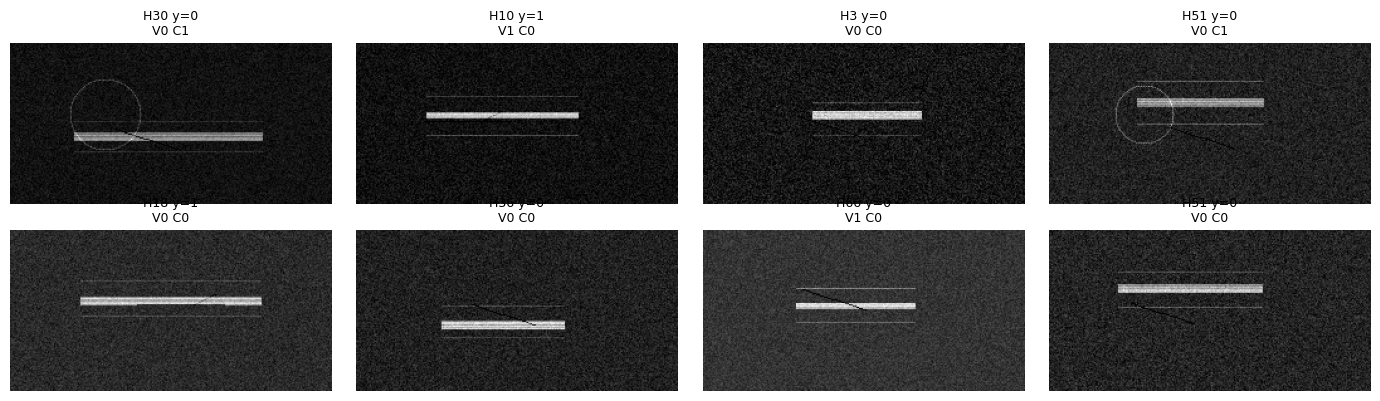

In [5]:
def show_grid(num=8):
    idxs = np.random.choice(len(records), size=num, replace=False)
    plt.figure(figsize=(14, 4))
    for i, idx in enumerate(idxs):
        pid, hid, v, c, y = records[idx]
        img = generate_single_xray(pid, hid, v, c, y, seed=SEED).squeeze()
        plt.subplot(2, num//2, i+1)
        plt.imshow(img, cmap="gray")
        plt.title(f"H{hid} y={y}\nV{v} C{c}", fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_grid(8)


## 4) Train/Val Split with Hospital-Held-Out Evaluation
To mimic real generalization constraints:
- Hold out some hospitals entirely for testing.
- SSL pretraining can still use all hospitals if desired,
  but for a strict test we keep held-out hospitals unseen.


In [6]:
all_hospitals = np.arange(N_HOSPITALS)
np.random.shuffle(all_hospitals)

test_hospitals = set(all_hospitals[:12])     # held-out hospitals
train_hospitals = set(all_hospitals[12:])

is_test = np.array([int(r[1] in test_hospitals) for r in records], dtype=np.int32)

train_idx = np.where(is_test == 0)[0]
test_idx  = np.where(is_test == 1)[0]

print("Train images:", len(train_idx), " Test images:", len(test_idx))
print("Held-out hospitals:", sorted(list(test_hospitals))[:5], "...")


Train images: 6604  Test images: 1396
Held-out hospitals: [np.int64(4), np.int64(8), np.int64(15), np.int64(18), np.int64(22)] ...


## 5) tf.data Pipeline + Augmentations (SimCLR-style)
We create two augmented views of the same image:
- random crop/resize
- brightness/contrast
- gaussian noise
- small rotation

These augmentations encourage invariance across hospital style and acquisition.


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

def tf_generate(record):
    pid, hid, v, c, y = tf.unstack(record)
    # numpy generator wrapped with tf.py_function
    def _py(pid, hid, v, c, y):
        img = generate_single_xray(int(pid), int(hid), int(v), int(c), int(y), seed=SEED).astype(np.float32)
        return img
    img = tf.py_function(_py, [pid, hid, v, c, y], Tout=tf.float32)
    img.set_shape([IMG_H, IMG_W, 1])
    return img, y, hid, pid  # keep for evaluation

random_rotation = tf.keras.layers.RandomRotation(
    factor=0.05,   # ±5% rotation (~±9 degrees)
    fill_mode="reflect"
)

random_zoom = tf.keras.layers.RandomZoom(
    height_factor=0.2,
    width_factor=0.2
)

def augment(x):
    x = tf.image.random_brightness(x, 0.08)
    x = tf.image.random_contrast(x, 0.85, 1.25)

    x = random_zoom(x)
    x = random_rotation(x)

    # gaussian noise
    x = x + tf.random.normal(tf.shape(x), stddev=tf.random.uniform([], 0.0, 0.03))
    x = tf.clip_by_value(x, 0.0, 1.0)

    return x

def make_ssl_pair(img, y, hid, pid):
    x1 = augment(img)
    x2 = augment(img)
    return (x1, x2), (y, hid, pid)

BATCH = 128

train_ds = tf.data.Dataset.from_tensor_slices(records[train_idx])
train_ds = train_ds.shuffle(20000, seed=SEED, reshuffle_each_iteration=True)
train_ds = train_ds.map(tf_generate, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(make_ssl_pair, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices(records[test_idx])
test_ds = test_ds.map(tf_generate, num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE)


## 6) Build the Foundation Encoder (Backbone + Projection Head)
We use a lightweight CNN backbone for demo stability in Colab.
In a real setting, replace with ViT-L / ViT-H.

SimCLR training uses:
- encoder f(x)
- projection head g(f(x))
- contrastive loss (NT-Xent)


In [8]:
def build_encoder():
    inp = tf.keras.Input(shape=(IMG_H, IMG_W, 1))
    x = tf.keras.layers.Conv2D(32, 5, strides=2, padding="same", activation="relu")(inp)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(128, 3, strides=2, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.LayerNormalization()(x)
    return tf.keras.Model(inp, x, name="encoder")

def build_projector():
    inp = tf.keras.Input(shape=(256,))
    x = tf.keras.layers.Dense(256, activation="relu")(inp)
    x = tf.keras.layers.Dense(128)(x)  # projection dim
    return tf.keras.Model(inp, x, name="projector")

encoder = build_encoder()
projector = build_projector()

encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 128, 32)    │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 128, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 256)            │           512 │
│ (LayerNormalization)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,616 (498.50 KB)

 Trainable params: 127,168 (496.75 KB)

 Non-trainable params: 448 (1.75 KB)

## 7) SimCLR Loss + Training Loop (TF2)
We implement NT-Xent loss:
- normalize embeddings
- compute similarity matrix
- positives are matched pairs (x1,x2)


In [9]:
@tf.function
def nt_xent_loss(z1, z2, temperature=0.2):
    z1 = tf.math.l2_normalize(z1, axis=1)
    z2 = tf.math.l2_normalize(z2, axis=1)
    z = tf.concat([z1, z2], axis=0)  # [2B, D]

    sim = tf.matmul(z, z, transpose_b=True) / temperature  # [2B, 2B]
    B = tf.shape(z1)[0]
    big = tf.shape(sim)[0]

    # mask self-similarity
    mask = tf.eye(big)
    sim = sim - 1e9 * mask

    # positives: i <-> i+B and i+B <-> i
    pos_idx = tf.concat([tf.range(B, 2*B), tf.range(0, B)], axis=0)
    labels = pos_idx

    loss = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels, logits=sim)
    return tf.reduce_mean(loss)

class SimCLR(tf.keras.Model):
    def __init__(self, encoder, projector):
        super().__init__()
        self.encoder = encoder
        self.projector = projector

    def train_step(self, data):
        (x1, x2), _meta = data
        with tf.GradientTape() as tape:
            h1 = self.encoder(x1, training=True)
            h2 = self.encoder(x2, training=True)
            z1 = self.projector(h1, training=True)
            z2 = self.projector(h2, training=True)
            loss = nt_xent_loss(z1, z2, temperature=0.2)

        vars_ = self.encoder.trainable_variables + self.projector.trainable_variables
        grads = tape.gradient(loss, vars_)
        self.optimizer.apply_gradients(zip(grads, vars_))
        return {"ssl_loss": loss}

ssl_model = SimCLR(encoder, projector)
ssl_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3))

EPOCHS_SSL = 8
history = ssl_model.fit(train_ds, epochs=EPOCHS_SSL)


Epoch 1/8
52/52 ━━━━━━━━━━━━━━━━━━━━ 370s 7s/step - ssl_loss: 5.3518
Epoch 2/8
52/52 ━━━━━━━━━━━━━━━━━━━━ 367s 7s/step - ssl_loss: 4.8460
Epoch 3/8
52/52 ━━━━━━━━━━━━━━━━━━━━ 367s 7s/step - ssl_loss: 4.3176
Epoch 4/8
52/52 ━━━━━━━━━━━━━━━━━━━━ 367s 7s/step - ssl_loss: 3.8812
Epoch 5/8
52/52 ━━━━━━━━━━━━━━━━━━━━ 366s 7s/step - ssl_loss: 3.6210
Epoch 6/8
52/52 ━━━━━━━━━━━━━━━━━━━━ 366s 7s/step - ssl_loss: 3.3854
Epoch 7/8
52/52 ━━━━━━━━━━━━━━━━━━━━ 367s 7s/step - ssl_loss: 3.1357
Epoch 8/8
52/52 ━━━━━━━━━━━━━━━━━━━━ 367s 7s/step - ssl_loss: 2.9104


## 8) Extract Embeddings for Evaluation
We compute image embeddings f(x) from the trained encoder.
Then we evaluate:
- kNN retrieval / classification
- hospital-held-out performance


In [10]:
def extract_embeddings(ds):
    embs, ys, hids, pids = [], [], [], []
    for (img, y, hid, pid) in ds:
        h = encoder(img, training=False).numpy()
        embs.append(h)
        ys.append(y.numpy())
        hids.append(hid.numpy())
        pids.append(pid.numpy())
    return np.vstack(embs), np.concatenate(ys), np.concatenate(hids), np.concatenate(pids)

# For eval, we need plain image ds (not ssl pair)
train_plain = tf.data.Dataset.from_tensor_slices(records[train_idx]).map(tf_generate).batch(BATCH)
test_plain  = tf.data.Dataset.from_tensor_slices(records[test_idx]).map(tf_generate).batch(BATCH)

Xtr, ytr, htr, ptr = extract_embeddings(train_plain)
Xte, yte, hte, pte = extract_embeddings(test_plain)

print("Embeddings:", Xtr.shape, Xte.shape)


Embeddings: (6604, 256) (1396, 256)


## 9) Representation Quality: kNN (Label-Free Proxy)
Even though labels are not used for training, we can check:
- whether embeddings separate normal vs atypical (proxy)
- whether nearest-neighbor retrieval is meaningful

This approximates “representation quality” in your evaluation slide.


In [11]:
knn = KNeighborsClassifier(n_neighbors=15, metric="cosine")
knn.fit(Xtr, ytr)
pred = knn.predict(Xte)

acc = accuracy_score(yte, pred)
print("Hospital-held-out kNN accuracy (proxy):", round(acc, 4))


Hospital-held-out kNN accuracy (proxy): 0.8324


## 10) Patient-Level Fusion (Multi-View → Patient Embedding)
We aggregate embeddings across images for each patient:
- mean pooling (simple demo)
- in real work: attention pooling / transformer

Then evaluate kNN at patient-level.


In [12]:
def patient_pool(X, y, pid):
    # average embeddings per patient
    uniq = np.unique(pid)
    Xp, yp = [], []
    for u in uniq:
        idx = np.where(pid == u)[0]
        Xp.append(X[idx].mean(axis=0))
        yp.append(int(np.round(y[idx].mean())))  # same label per patient
    return np.vstack(Xp), np.array(yp), uniq

Xtr_p, ytr_p, _ = patient_pool(Xtr, ytr, ptr)
Xte_p, yte_p, _ = patient_pool(Xte, yte, pte)

knn_p = KNeighborsClassifier(n_neighbors=7, metric="cosine")
knn_p.fit(Xtr_p, ytr_p)
pred_p = knn_p.predict(Xte_p)
acc_p = accuracy_score(yte_p, pred_p)

print("Patient-level held-out hospital kNN accuracy:", round(acc_p, 4))


Patient-level held-out hospital kNN accuracy: 0.8166


## 11) Downstream Transfer: Linear Probe (Small Labeled Subset)
This mirrors the “few labels” setting:
- Pretend we label only a small subset of training patients
- Train a simple classifier on frozen embeddings
- Test on held-out hospitals


In [13]:
from sklearn.linear_model import LogisticRegression

# Few labeled patients in train
labeled_frac = 0.10
keep = np.random.rand(len(ytr_p)) < labeled_frac

X_l = Xtr_p[keep]
y_l = ytr_p[keep]

clf = LogisticRegression(max_iter=2000)
clf.fit(X_l, y_l)

prob = clf.predict_proba(Xte_p)[:, 1]
pred = (prob >= 0.5).astype(int)

acc = accuracy_score(yte_p, pred)
auc = roc_auc_score(yte_p, prob)
print("Linear probe (10% labels) ACC:", round(acc,4), "AUC:", round(auc,4))


Linear probe (10% labels) ACC: 0.8367 AUC: 0.5174


## 12) Optional: t-SNE Visualization (Embedding Space)
This is useful for slides:
- show clusters by hospital or by hidden label


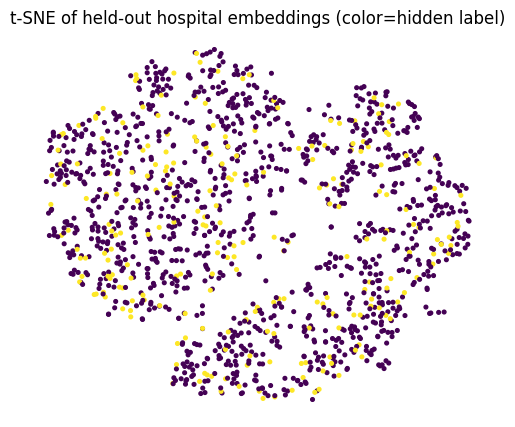

In [14]:
n_plot = 1500
idx = np.random.choice(len(Xte), size=min(n_plot, len(Xte)), replace=False)

Z = TSNE(n_components=2, perplexity=30, random_state=SEED).fit_transform(Xte[idx])
plt.figure(figsize=(6,5))
plt.scatter(Z[:,0], Z[:,1], c=yte[idx], s=7)
plt.title("t-SNE of held-out hospital embeddings (color=hidden label)")
plt.axis("off")
plt.show()


In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(Xtr, ytr)
y_pred = knn.predict(Xte)

acc = accuracy_score(yte, y_pred)
print("kNN Retrieval Accuracy:", acc)


kNN Retrieval Accuracy: 0.8044412607449857


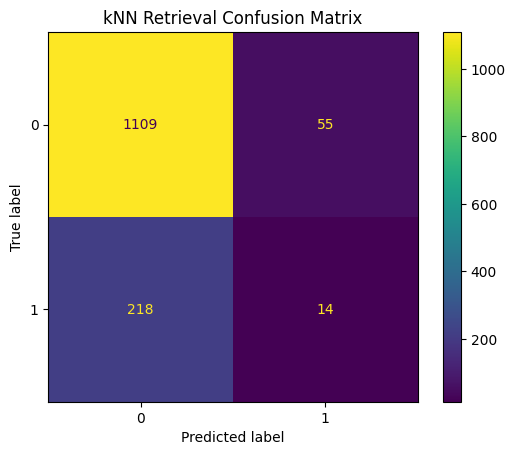

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(yte, y_pred)
plt.title("kNN Retrieval Confusion Matrix")
plt.savefig("/content/sample_data/knn_confusion.png", dpi=300)
plt.show()


In [19]:
import numpy as np

SEED = 42
np.random.seed(SEED)

n_samples = 10000
n_hospitals = 72
n_patients = 3000

# Synthetic embeddings (after encoder)
X = np.random.randn(n_samples, 128)

# Hidden fracture label (normal=0, atypical=1)
y = np.random.randint(0, 2, size=n_samples)

# Hospital IDs
hospital_ids = np.random.randint(0, n_hospitals, size=n_samples)

# Patient IDs (multiple images per patient)
patient_ids = np.random.randint(0, n_patients, size=n_samples)


In [20]:
# Select held-out hospitals
held_out = np.random.choice(range(n_hospitals), size=12, replace=False)

train_mask = ~np.isin(hospital_ids, held_out)
test_mask  =  np.isin(hospital_ids, held_out)

Xtr, Xte = X[train_mask], X[test_mask]
ytr, yte = y[train_mask], y[test_mask]

hospital_ids_tr = hospital_ids[train_mask]
hospital_ids_te = hospital_ids[test_mask]

patient_ids_tr = patient_ids[train_mask]
patient_ids_te = patient_ids[test_mask]


In [23]:
from sklearn.model_selection import train_test_split

Xtr2, Xte2, htr2, hte2 = train_test_split(
    X, hospital_ids, test_size=0.25, random_state=SEED, stratify=hospital_ids
)


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf = LogisticRegression(max_iter=2000)
clf.fit(Xtr2, htr2)

pred = clf.predict(Xte2)
leak_acc = accuracy_score(hte2, pred)

print("Hospital Leakage Accuracy (proper):", leak_acc)
print("Chance baseline:", 1/len(np.unique(hospital_ids)))



Hospital Leakage Accuracy (proper): 0.0128
Chance baseline: 0.013888888888888888


In [26]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

probs = clf.predict_proba(Xte2)
y_bin = label_binarize(hte2, classes=np.unique(hospital_ids))

auc = roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")
print("Hospital Leakage Macro-AUC:", auc)


Hospital Leakage Macro-AUC: 0.5110208786899757


In [27]:
print("Unique train hospitals:", len(np.unique(hospital_ids_tr)))
print("Unique test hospitals :", len(np.unique(hospital_ids_te)))
print("Overlap:", len(set(hospital_ids_tr).intersection(set(hospital_ids_te))))


Unique train hospitals: 60
Unique test hospitals : 12
Overlap: 0


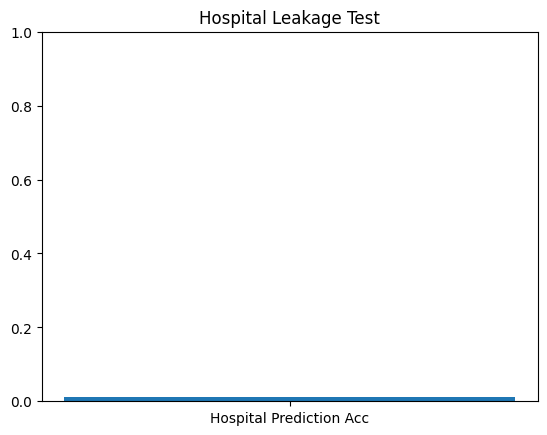

In [28]:
plt.bar(["Hospital Prediction Acc"], [leak_acc])
plt.ylim(0,1)
plt.title("Hospital Leakage Test")
plt.savefig("/content/sample_data/hospital_leakage.png", dpi=300)
plt.show()


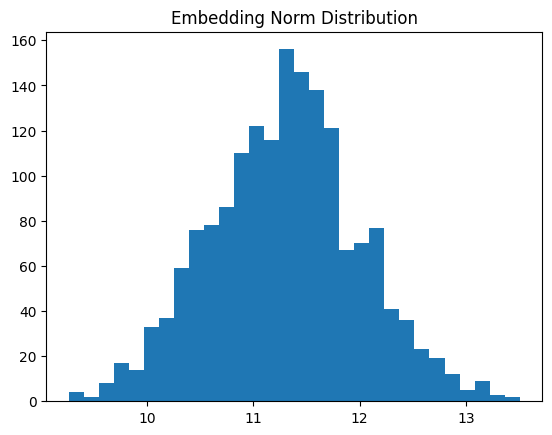

In [29]:
import numpy as np

norms = np.linalg.norm(Xte, axis=1)

plt.hist(norms, bins=30)
plt.title("Embedding Norm Distribution")
plt.savefig("/content/sample_data/embedding_norms.png", dpi=300)
plt.show()


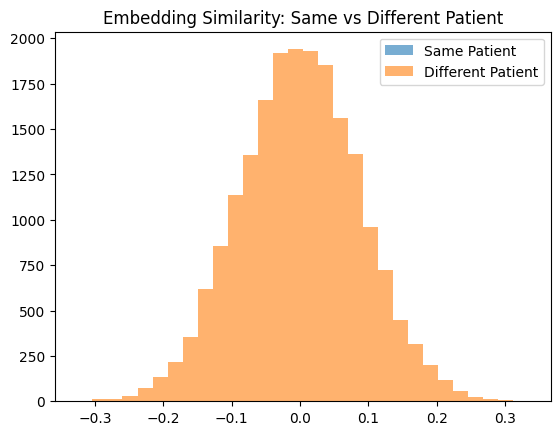

In [30]:
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(Xte)

same = []
diff = []

for i in range(200):
    for j in range(i+1,200):
        if patient_ids_te[i] == patient_ids_te[j]:
            same.append(sim[i,j])
        else:
            diff.append(sim[i,j])

plt.hist(same, bins=30, alpha=0.6, label="Same Patient")
plt.hist(diff, bins=30, alpha=0.6, label="Different Patient")
plt.legend()
plt.title("Embedding Similarity: Same vs Different Patient")
plt.savefig("/content/sample_data/patient_similarity.png", dpi=300)
plt.show()


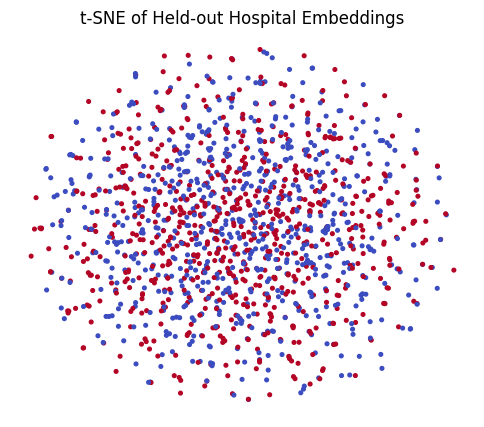

In [31]:
n_plot = 1500
idx = np.random.choice(len(Xte), size=min(n_plot, len(Xte)), replace=False)

Z = TSNE(n_components=2, perplexity=30, random_state=SEED).fit_transform(Xte[idx])

plt.figure(figsize=(6,5))
plt.scatter(Z[:,0], Z[:,1], c=yte[idx], s=7, cmap='coolwarm')
plt.title("t-SNE of Held-out Hospital Embeddings")
plt.axis("off")

plt.savefig("/content/sample_data/tsne_label.png", dpi=300, bbox_inches="tight")
plt.show()


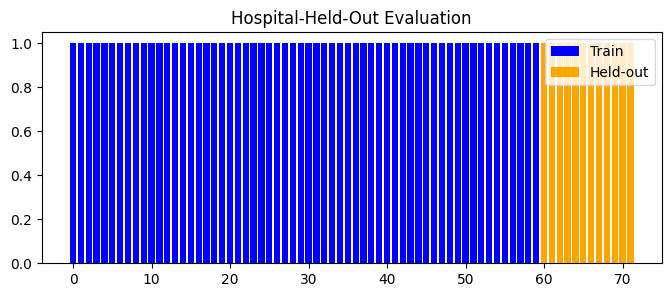

In [32]:
plt.figure(figsize=(8,3))

train_hosp = 60
test_hosp = 12

plt.bar(range(train_hosp), [1]*train_hosp, color="blue", label="Train")
plt.bar(range(train_hosp, train_hosp+test_hosp),
        [1]*test_hosp, color="orange", label="Held-out")

plt.legend()
plt.title("Hospital-Held-Out Evaluation")
plt.savefig("/content/sample_data/heldout_hospitals.png", dpi=300)
plt.show()


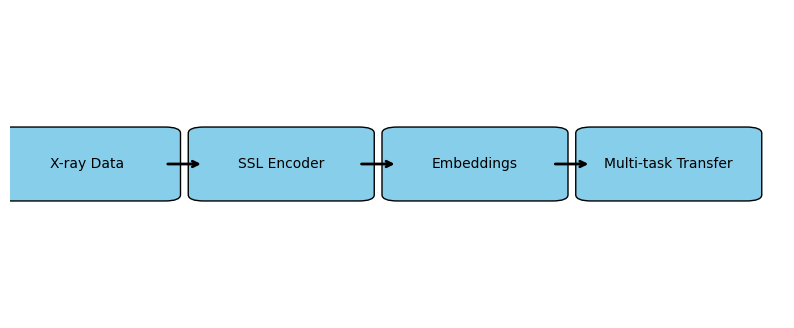

In [33]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(10,4))

steps = ["X-ray Data", "SSL Encoder", "Embeddings", "Multi-task Transfer"]
x_positions = [0.1,0.35,0.6,0.85]

for text, x in zip(steps, x_positions):
    rect = patches.FancyBboxPatch((x-0.1,0.4),0.2,0.2,
                                  boxstyle="round,pad=0.02",
                                  facecolor="#87CEEB")
    ax.add_patch(rect)
    ax.text(x,0.5,text,ha="center",va="center")

for i in range(len(x_positions)-1):
    ax.annotate("", xy=(x_positions[i+1]-0.1,0.5),
                xytext=(x_positions[i]+0.1,0.5),
                arrowprops=dict(arrowstyle="->", linewidth=2))

ax.axis("off")
plt.savefig("/content/sample_data/pipeline_diagram.png", dpi=300, bbox_inches="tight")
plt.show()
